In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"C:\Users\Dev\Downloads\google_2year_data.xls")
df = data.copy()
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2024-03-13,138.64410400390625,139.9334506450809,137.85067388660744,137.86058646627538,23347200
3,2024-03-14,141.92697143554688,142.41294506959082,139.30861293112127,140.03262465964323,42753400
4,2024-03-15,140.022705078125,142.00631057950346,138.88213796831596,141.33189197321508,49475400


In [3]:
df.head()
df = df.drop(index = [0,1],axis=0)

In [4]:
df = df.reset_index(drop=True)
df.head()


,Price,Close,High,Low,Open,Volume
0,2024-03-13,138.64410400390625,139.9334506450809,137.85067388660744,137.86058646627538,23347200
1,2024-03-14,141.92697143554688,142.41294506959082,139.30861293112127,140.03262465964323,42753400
2,2024-03-15,140.022705078125,142.00631057950346,138.88213796831596,141.33189197321508,49475400
3,2024-03-18,146.46942138671875,150.9027808454485,145.96360743742733,147.39180580449582,69273700
4,2024-03-19,145.8247528076172,147.57032014783982,144.882543249734,146.9454947247472,24070400


In [5]:
df.info()

# Renaming price column to Date
col = list(df.columns)
col[0] = "Date"
col

df2 = pd.DataFrame(df,columns = col)
df2['Date'] = df['Price']

print(df2.columns)

del df
df = df2
del df2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   502 non-null    object
 1   Close   502 non-null    object
 2   High    502 non-null    object
 3   Low     502 non-null    object
 4   Open    502 non-null    object
 5   Volume  502 non-null    object
dtypes: object(6)
memory usage: 23.7+ KB
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [6]:
#  Correcting data types
col = df.columns

df[col[0]] = pd.to_datetime(df[col[0]])

for i in range(1,len(col)):
    df[col[i]] = pd.to_numeric(df[col[i]])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    502 non-null    datetime64[ns]
 1   Close   502 non-null    float64       
 2   High    502 non-null    float64       
 3   Low     502 non-null    float64       
 4   Open    502 non-null    float64       
 5   Volume  502 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 23.7 KB


# Visualization

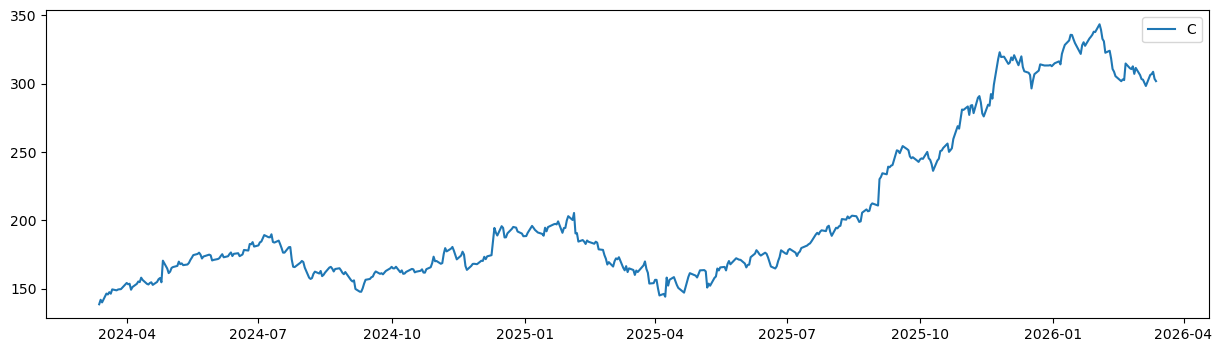

In [7]:
plt.figure(figsize=(15,4))
plt.plot(df['Date'],df.iloc[:,1])
plt.legend('Close')

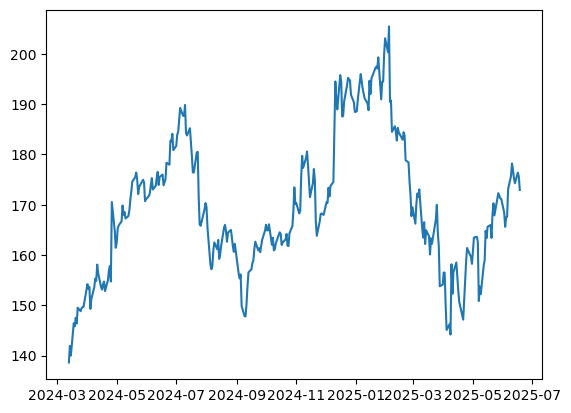

In [8]:
# Visualizing Part wise 
df['Date'].values 
start_idx = df['Date'][df['Date'] == '2024-03-18'].index[0]
end_idx = df['Date'][df['Date'] == '2025-06-18'].index[0]

plt.plot(df['Date'].iloc[:end_idx+1],df['Close'].iloc[:end_idx+1])
# end_idx


In [9]:
from statsmodels.tsa.stattools import adfuller
adfuller(df['Close'])[1]

def is_trend(col,max_d=5):

    """"This function will check whether a series is stationary/trend at dth difference. 
    It will from difference 1 to n"""
    
    if adfuller(col)[1] < 0.05 :
        return 'Series is stationary at no difference'
    
    else:
        for d in range(1,max_d+1):
            p_val = adfuller(col.diff(d).dropna())[1]

            if p_val < 0.05:     
                 return f'Series is stationary at difference d = {d}'
            
            elif d == max_d and p_val >= 0.05 : 
                return f'Series is Non stationary till difference d = {d}'
            
            else:
                pass

'Series is stationary at no difference'

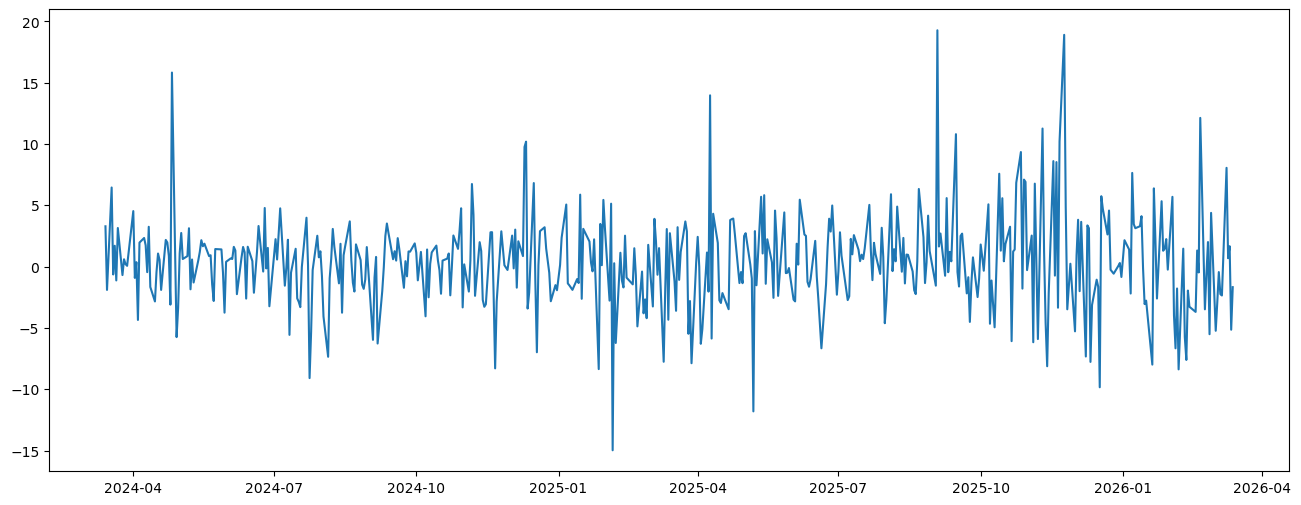

In [10]:
# From the above plots it is found that the series is stationary 
# Finding differnece d at which it become stationary 

is_trend(df['Close'])
# d = 1
df2 = df.copy()
df2['Close2'] = df2['Close'].diff(1)
df2 = df2.dropna()

plt.figure(figsize=(16,6))
plt.plot(df2['Date'],df2['Close2'])

is_trend(df2['Close2'])

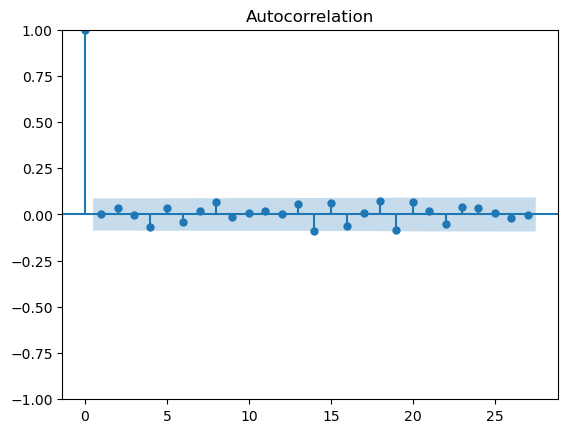

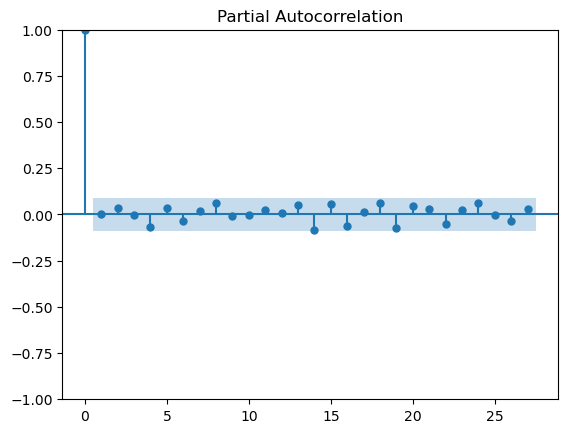

In [11]:
df2['Close2']

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df2['Close2'])   # q = 0
plt.show()
plot_pacf(df2['Close2'])
plt.show()

In [12]:
# Checking Stationarity of Each Exogenous Variablec 

is_trend(df.High)          # d = 1
is_trend(df.Low)          # d = 1
is_trend(df.Open)          # d = 1
is_trend(df.Volume)          # already stationary

'Series is stationary at no difference'

In [13]:
df3 = df.copy()
df3.head(2)

,Date,Close,High,Low,Open,Volume
0,2024-03-13,138.644104,139.933451,137.850674,137.860586,23347200
1,2024-03-14,141.926971,142.412945,139.308613,140.032625,42753400


In [14]:
df3['High_stationarized'] = df3['High'].diff(1)
df3['Low_stationarized'] = df3['Low'].diff(1)
df3['Open_stationarized'] = df3['Open'].diff(1)
df3['Volume_stationary'] = df3['Volume']
df3['Close_stationary'] = df['Close'].diff(1)

df3 = df3.dropna()

In [15]:
df3
# Using granger casuality to find which variable is homogeneous    ## condtm Xi,Y ,must be stationary   # if p_val < 0.05 then Xi granger causes Y

from statsmodels.tsa.stattools import grangercausalitytests
grangercausalitytests(pd.concat([df3.Close_stationary,df3.High_stationarized],axis=1),maxlag=10)   # lag = 6

grangercausalitytests(pd.concat([df3.Close_stationary,df3.Low_stationarized],axis=1),maxlag=10)   # lag = 9

grangercausalitytests(pd.concat([df3.Close_stationary,df3.Open_stationarized],axis=1),maxlag=10)   # lag = 7

grangercausalitytests(pd.concat([df3.Close_stationary,df3.Volume_stationary],axis=1),maxlag=10)   # Not have any predictive power 


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.8366  , p=0.3608  , df_denom=497, df_num=1
ssr based chi2 test:   chi2=0.8417  , p=0.3589  , df=1
likelihood ratio test: chi2=0.8410  , p=0.3591  , df=1
parameter F test:         F=0.8366  , p=0.3608  , df_denom=497, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.9225  , p=0.3982  , df_denom=494, df_num=2
ssr based chi2 test:   chi2=1.8636  , p=0.3938  , df=2
likelihood ratio test: chi2=1.8601  , p=0.3945  , df=2
parameter F test:         F=0.9225  , p=0.3982  , df_denom=494, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.6133  , p=0.6066  , df_denom=491, df_num=3
ssr based chi2 test:   chi2=1.8662  , p=0.6006  , df=3
likelihood ratio test: chi2=1.8627  , p=0.6014  , df=3
parameter F test:         F=0.6133  , p=0.6066  , df_denom=491, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.7021  , p=0.5908  

{np.int64(1): ({'ssr_ftest': (np.float64(0.7507226800371196),
    np.float64(0.386665609919961),
    np.float64(497.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.7552542052687321),
    np.float64(0.38481779982125064),
    np.int64(1)),
   'lrtest': (np.float64(0.7546843701088619),
    np.float64(0.38499717204040995),
    np.int64(1)),
   'params_ftest': (np.float64(0.7507226800371224),
    np.float64(0.386665609919961),
    np.float64(497.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(1.9224051777893998),
    np.float64(0.147347326565998),
    np.float64(494.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(3.883725440149435),
    np.float64(0.1434365186975826),
    np.int64(2)),
   'lrtest': (np.float64(3.868689854177319),
    np.float64(0.14451890824426455),
    np.int64(2)),
   'params_ftest': (np.float64(1.9224051783222347),
    np.float64(0.14734732648809276),
    np.float64(494.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
       

# Starting Traditional Modelling


In [16]:
df4 = df.copy()
df4['Lag_6_High'] = df4.High.shift(6)

df4['Lag_9_Low'] = df4.Low.shift(9)

df4['Lag_7_Open'] = df4.Open.shift(6)

df4 = df4.dropna().reset_index(drop=True)
df4.head(1)


,Date,Close,High,Low,Open,Volume,Lag_6_High,Lag_9_Low,Lag_7_Open
0,2024-03-26,149.434921,151.011884,148.750575,148.988613,22149100,150.902781,137.850674,147.391806


In [17]:
Y_t = df4.Close
X_exog = df4.iloc[:,6:]

# Divivding dataset into 80-20 part
idx = int(len(Y_t)*0.8)

# Training
Y_t__train = Y_t.iloc[:idx+1]
X_exog__train = X_exog.iloc[:idx+1]

# Testing
Y_t__test = Y_t.iloc[idx+1:]
X_exog__test = X_exog.iloc[idx+1:]

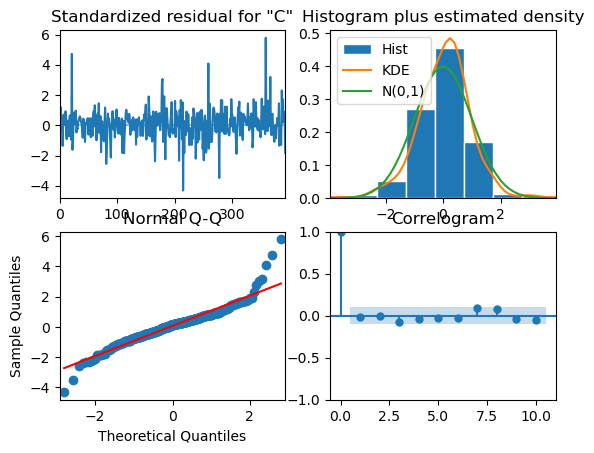

In [18]:
from statsmodels.tsa.arima.model import ARIMA
m1 = ARIMA(Y_t__train ,order =(0,1,0), exog=X_exog__train).fit()
m1.summary()
m1.plot_diagnostics()
plt.show()

In [19]:
order = [(1,1,0),(0,1,0),(0,1,1),
         (2,1,1),(2,1,0),(2,1,2),
         (3,1,1),(3,1,0),(3,1,2)]

RMSE = []
MAPE = []
AIC = []

for i in order:
    from statsmodels.tsa.arima.model import ARIMA
    m1 = ARIMA(Y_t__train ,order =i, exog=X_exog__train).fit()


    # Dataframe for prediction 
    predicted = pd.DataFrame()
    predicted['Date'] = df4['Date'].iloc[idx+1:]
    predicted['Org_Y'] = Y_t__test
    predicted['Y_hat'] = m1.forecast(len(X_exog__test),exog=X_exog__test)
    predicted['Resid'] = predicted.Org_Y - predicted.Y_hat

    from sklearn.metrics import mean_squared_error  , mean_absolute_percentage_error

    rmse = (mean_squared_error(predicted.Org_Y,predicted.Y_hat))**0.5
    mape = mean_absolute_percentage_error(predicted.Org_Y,predicted.Y_hat)

    RMSE.append(rmse)
    MAPE.append(mape*100)
    AIC.append(m1.aic)

Score = pd.DataFrame({'ARIMA':order,
                     'RMSE':RMSE,
                     'MAPE':MAPE,
                     'AIC':AIC})

c:\Users\Dev\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Dev\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Dev\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [20]:
Score

,ARIMA,RMSE,MAPE,AIC
0,"(1, 1, 0)",54.592613,16.448457,2088.571597
1,"(0, 1, 0)",54.748642,16.499359,2086.642107
2,"(0, 1, 1)",54.592516,16.448452,2088.572325
3,"(2, 1, 1)",54.954537,16.561159,2092.296683
4,"(2, 1, 0)",54.683853,16.476679,2090.557380
5,"(2, 1, 2)",54.115952,16.303086,2094.104186
6,"(3, 1, 1)",54.782365,16.511545,2092.303029
7,"(3, 1, 0)",54.839237,16.525190,2090.843229
8,"(3, 1, 2)",55.572587,16.725009,2089.790134


In [21]:
sea_order = [(1,1,0,5),(0,1,0,5),(0,1,1,5),
         (2,1,1,20),(2,1,0,20),(2,1,2,20),
         (3,1,1,40),(3,1,0,40),(3,1,2,40)]

RMSE = []
MAPE = []
AIC = []

for i in sea_order:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    m1 = SARIMAX(Y_t__train ,order =(0,1,0), exog=X_exog__train,seasonal_order=i).fit()


    # Dataframe for prediction 
    predicted = pd.DataFrame()
    predicted['Date'] = df4['Date'].iloc[idx+1:]
    predicted['Org_Y'] = Y_t__test
    predicted['Y_hat'] = m1.forecast(len(X_exog__test),exog=X_exog__test)
    predicted['Resid'] = predicted.Org_Y - predicted.Y_hat

    from sklearn.metrics import mean_squared_error  , mean_absolute_percentage_error

    rmse = (mean_squared_error(predicted.Org_Y,predicted.Y_hat))**0.5
    mape = mean_absolute_percentage_error(predicted.Org_Y,predicted.Y_hat)

    RMSE.append(rmse)
    MAPE.append(mape*100)
    AIC.append(m1.aic)

Score = pd.DataFrame({'SARIMA':sea_order,
                     'RMSE':RMSE,
                     'MAPE':MAPE,
                     'AIC':AIC})

KeyboardInterrupt: 

In [22]:
from joblib import Parallel, delayed

In [23]:
sea_order = [(1,1,0,5),(0,1,0,5),(0,1,1,5),
         (2,1,1,20),(2,1,0,20),(2,1,2,20),
         (3,1,1,40),(3,1,0,40),(3,1,2,40)]

def run_model(i):

    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

    model = SARIMAX(
        Y_t__train,
        order=(0,1,0),
        exog=X_exog__train,
        seasonal_order=i
    ).fit(disp=False)

    forecast = model.forecast(len(X_exog__test), exog=X_exog__test)

    rmse = (mean_squared_error(Y_t__test, forecast))**0.5
    mape = mean_absolute_percentage_error(Y_t__test, forecast)

    return {
        'SARIMA': i,
        'RMSE': rmse,
        'MAPE': mape*100,
        'AIC': model.aic
    }

results = Parallel(n_jobs=-1)(
    delayed(run_model)(i) for i in sea_order
)

In [24]:
Score = pd.DataFrame(results)
Score

,SARIMA,RMSE,MAPE,AIC
0,"(1, 1, 0, 5)",23.912714,6.966676,2235.352445
1,"(0, 1, 0, 5)",25.700260,6.361882,2339.354960
2,"(0, 1, 1, 5)",38.203498,11.148594,2079.559367
3,"(2, 1, 1, 20)",41.717335,12.349415,2031.751340
4,"(2, 1, 0, 20)",22.872084,6.698753,2098.416519
5,"(2, 1, 2, 20)",41.618111,12.288343,2031.321254
6,"(3, 1, 1, 40)",35.821647,10.282371,1955.385501
7,"(3, 1, 0, 40)",28.202031,7.973853,1966.199093
8,"(3, 1, 2, 40)",35.791961,10.269965,1957.284000


# Model SARIMAX(0,1,0)(2,1,0,20);s=20 ie 1 month (it is daily recods) is chosen because
- Having Lowest RMSE
- Approx minimum MAPE
- Mediocre AIC

In [25]:
sarima = SARIMAX(Y_t__train,exog=X_exog__train,order=(0,1,0), seasonal_order=(2,1,0,20)).fit()

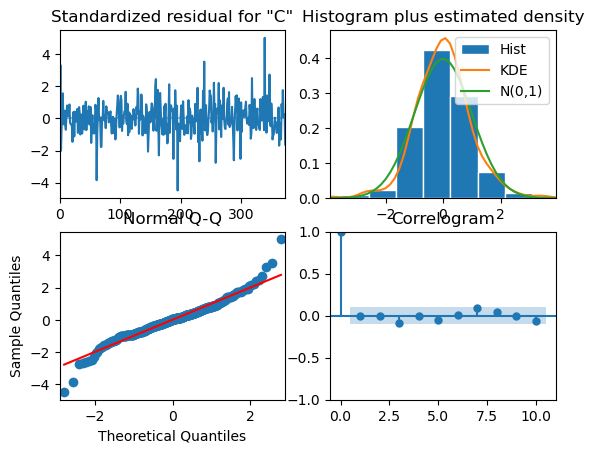

In [26]:
sarima.plot_diagnostics()
plt.show()


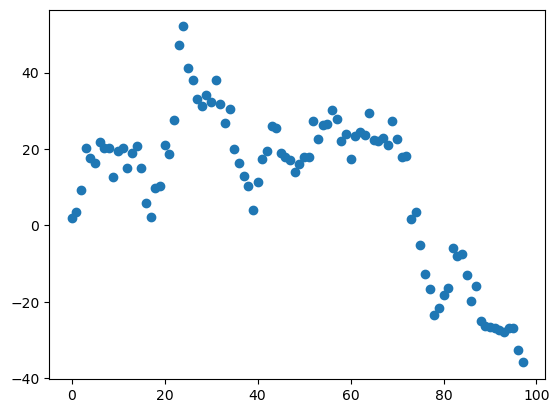

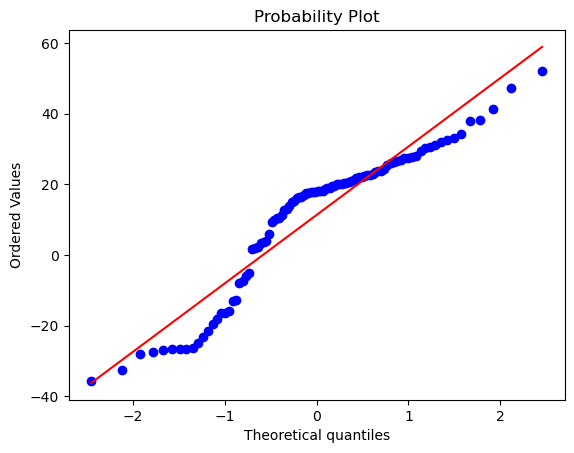

In [27]:

plt.scatter(range(len((Y_t__test - sarima.forecast(len(X_exog__test), exog = X_exog__test)))),(Y_t__test - sarima.forecast(len(X_exog__test), exog = X_exog__test)))
plt.show()
from scipy.stats import probplot
probplot(((Y_t__test - sarima.forecast(len(X_exog__test), exog = X_exog__test))),plot=plt)
plt.show()


# Since Residual contains PAttern 

<Axes: ylabel='Density'>

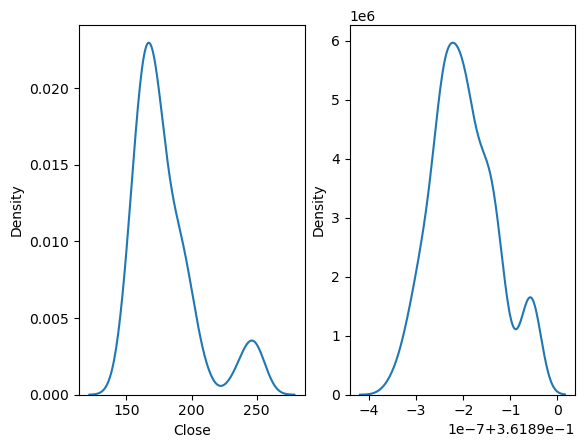

In [28]:
# let us apply transfromation and rebuild model
# Applying BOXCOX

from scipy.stats import boxcox

Y_t_bc , lamda = boxcox(Y_t)

# Divivding dataset into 80-20 part
idx = int(len(Y_t)*0.8)

Y_t_bc = pd.Series(Y_t_bc)
# Training
Y_t__train_bc = Y_t_bc.iloc[:idx+1]
X_exog__train = X_exog.iloc[:idx+1]

# Testing
Y_t__test_bc = Y_t.iloc[idx+1:]
X_exog__test = X_exog.iloc[idx+1:]


plt.subplot(1,2,1)
sns.kdeplot(Y_t__train)
# plt.show()
plt.subplot(1,2,2)
sns.kdeplot(Y_t__train_bc)
# bc[1]

### Now distn become roughly normal  

# Rebuilding model

In [29]:
sea_order = [(1,1,0,5),(0,1,0,5),(0,1,1,5),
             (2,1,0,5),(2,1,2,50),
         (2,1,1,20),(2,1,0,20),(2,1,2,20),
         (3,1,1,40),(3,1,0,40),(3,1,2,40)]

def run_model(i):

    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

    model = SARIMAX(
        Y_t__train,
        order=(0,1,0),
        exog=X_exog__train,
        seasonal_order=i
    ).fit(disp=False)

    forecast = model.forecast(len(X_exog__test), exog=X_exog__test)

    rmse = (mean_squared_error(Y_t__test, forecast))**0.5
    mape = mean_absolute_percentage_error(Y_t__test, forecast)

    return {
        'SARIMA': i,
        'RMSE': rmse,
        'MAPE': mape*100,
        'AIC': model.aic
    }

results = Parallel(n_jobs=-1)(
    delayed(run_model)(i) for i in sea_order
)

In [30]:
Score = pd.DataFrame(results)
Score

,SARIMA,RMSE,MAPE,AIC
0,"(1, 1, 0, 5)",23.912714,6.966676,2235.352445
1,"(0, 1, 0, 5)",25.700260,6.361882,2339.354960
2,"(0, 1, 1, 5)",38.203498,11.148594,2079.559367
3,"(2, 1, 0, 5)",32.033556,8.818634,2167.087115
4,"(2, 1, 2, 50)",37.970647,11.098685,1935.042489
5,"(2, 1, 1, 20)",41.717335,12.349415,2031.751340
6,"(2, 1, 0, 20)",22.872084,6.698753,2098.416519
7,"(2, 1, 2, 20)",41.618111,12.288343,2031.321254
8,"(3, 1, 1, 40)",35.821647,10.282371,1955.385501
9,"(3, 1, 0, 40)",28.202031,7.973853,1966.199093


# Again Model SARIMAX(0,1,0)(2,1,0,20);s=20 ie 1 month is chosen because
- Having Lowest RMSE
- Approx minimum MAPE
- Mediocre AIC

In [31]:

sarima = SARIMAX(Y_t__train_bc,exog=X_exog__train,order=(0,1,0), seasonal_order=(2,1,0,20)).fit()

c:\Users\Dev\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


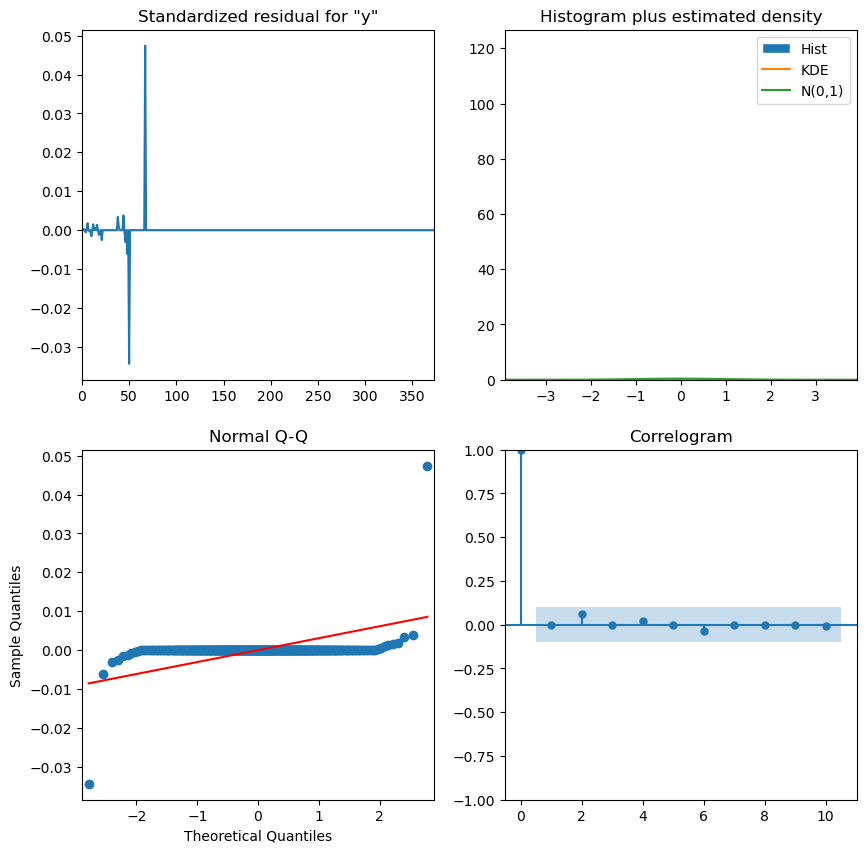

In [32]:

sarima.plot_diagnostics(figsize=(10,10))
plt.show()

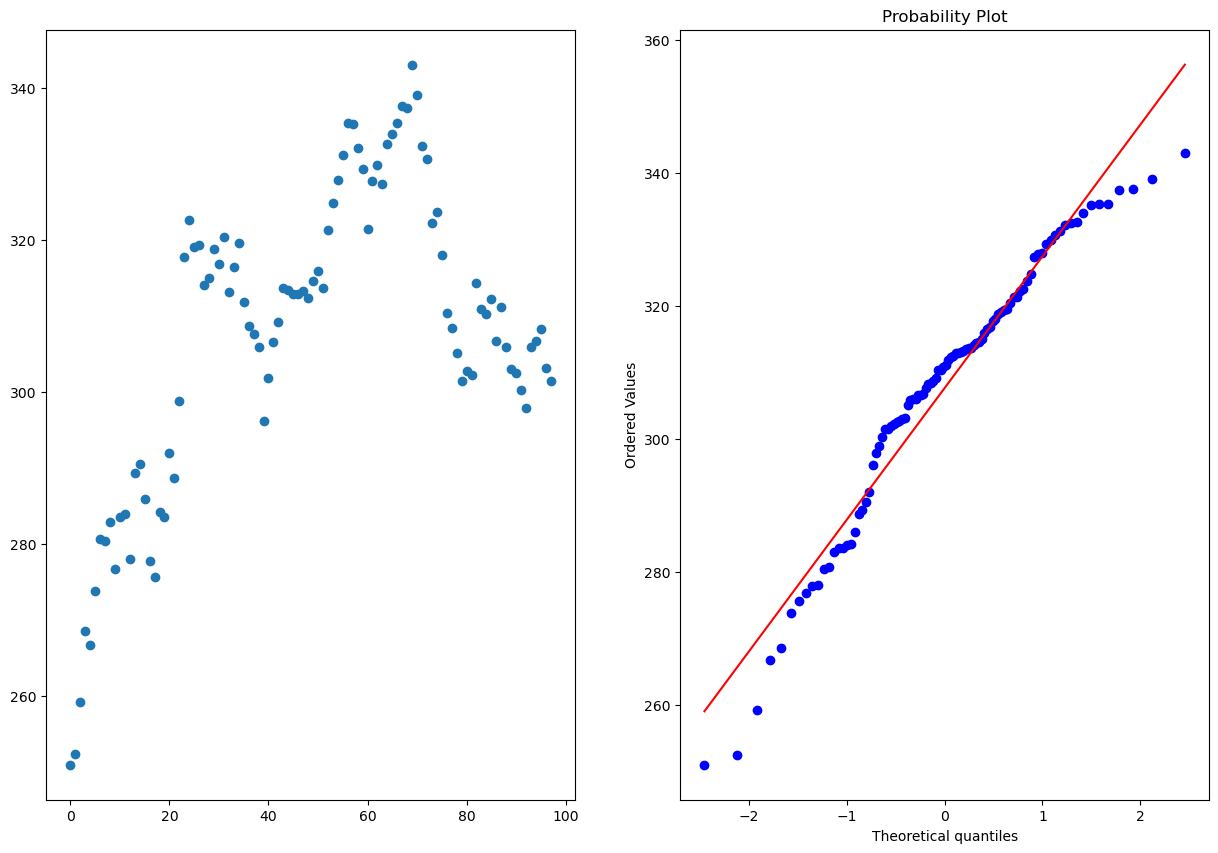

308.3118084018117

In [33]:
resid = Y_t__test_bc.values - sarima.forecast(steps= len(X_exog__test), exog = X_exog__test)

# Again plotting resid
plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
plt.scatter(range(len(resid)),resid)

plt.subplot(1,2,2)
probplot(resid , plot = plt)
plt.show()

mean_squared_error(Y_t__test_bc,sarima.forecast(steps= len(X_exog__test), exog = X_exog__test))**(0.5)

In [34]:
Close_bc ,lamb = boxcox(df['Close'])

In [35]:
df3
# Using granger casuality to find which variable is homogeneous    ## condtm Xi,Y ,must be stationary   # if p_val < 0.05 then Xi granger causes Y
df
from statsmodels.tsa.stattools import grangercausalitytests
grangercausalitytests(pd.concat([pd.Series(Close_bc).diff(1).dropna(),df3.High_stationarized],axis=1),maxlag=10)   # not have predictive power

grangercausalitytests(pd.concat([pd.Series(Close_bc).diff(1).dropna(),df3.Low_stationarized],axis=1),maxlag=10)   # lag = 9

grangercausalitytests(pd.concat([pd.Series(Close_bc).diff(1).dropna(),df3.Open_stationarized],axis=1),maxlag=10)   # lag = 7

grangercausalitytests(pd.concat([pd.Series(Close_bc).diff(1).dropna(),df3.Volume_stationary],axis=1),maxlag=10)   # Not have any predictive power 


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.2975  , p=0.5857  , df_denom=497, df_num=1
ssr based chi2 test:   chi2=0.2993  , p=0.5843  , df=1
likelihood ratio test: chi2=0.2992  , p=0.5844  , df=1
parameter F test:         F=0.2975  , p=0.5857  , df_denom=497, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.2239  , p=0.2950  , df_denom=494, df_num=2
ssr based chi2 test:   chi2=2.4725  , p=0.2905  , df=2
likelihood ratio test: chi2=2.4664  , p=0.2914  , df=2
parameter F test:         F=1.2239  , p=0.2950  , df_denom=494, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.1874  , p=0.9050  , df_denom=491, df_num=3
ssr based chi2 test:   chi2=0.5701  , p=0.9032  , df=3
likelihood ratio test: chi2=0.5698  , p=0.9033  , df=3
parameter F test:         F=0.1874  , p=0.9050  , df_denom=491, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.3435  , p=0.8486  

{np.int64(1): ({'ssr_ftest': (np.float64(-0.8230922280203696),
    np.float64(1.0),
    np.float64(498.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(-0.8263978192975598),
    np.float64(1.0),
    np.int64(1)),
   'lrtest': (np.float64(-0.8270815060823224), np.float64(1.0), np.int64(1)),
   'params_ftest': (np.float64(0.9837549931286189),
    np.float64(0.3217551794028658),
    np.float64(498.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(1.1609540432425605),
    np.float64(0.314036792447532),
    np.float64(496.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(2.335951885395313),
    np.float64(0.31099577792539096),
    np.int64(2)),
   'lrtest': (np.float64(2.33050128283503),
    np.float64(0.31184449109132684),
    np.int64(2)),
   'params_ftest': (np.float64(2.6595280389723124),
    np.float64(0.07097916359268076),
    np.float64(496.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])]),
 np.int64(3): ({'ssr_

In [36]:
Y = pd.Series(Close_bc).diff(1)
index = int(len(Y)*0.8)
Y_train = Y.iloc[:index+1]
Y_test = Y.iloc[index+1:]

In [37]:
order = [(1,1,0),(0,1,0),(0,1,1),
         (2,1,1),(2,1,0),(2,1,2),
         (3,1,1),(3,1,0),(3,1,2),
         (2,0,2)]

RMSE = []
MAPE = []
AIC = []

for i in order:
    from statsmodels.tsa.arima.model import ARIMA
    m1 = ARIMA( Y_train,order =i).fit()


    # Dataframe for prediction 
    predicted = pd.DataFrame()
    predicted['Date'] = df4['Date'].iloc[index+1:]
    predicted['Org_Y'] = Y_t__test
    predicted['Y_hat'] = m1.forecast(len(Y_test))
    predicted['Resid'] = predicted.Org_Y - predicted.Y_hat

    from sklearn.metrics import mean_squared_error  , mean_absolute_percentage_error

    rmse = (mean_squared_error(predicted.Org_Y,predicted.Y_hat))**0.5
    mape = mean_absolute_percentage_error(predicted.Org_Y,predicted.Y_hat)

    RMSE.append(rmse)
    MAPE.append(mape*100)
    AIC.append(m1.aic)

Score = pd.DataFrame({'ARIMA':order,
                     'RMSE':RMSE,
                     'MAPE':MAPE,
                     'AIC':AIC})

c:\Users\Dev\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Dev\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Dev\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Dev\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Dev\anaconda3\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid va

In [38]:
Score

,ARIMA,RMSE,MAPE,AIC
0,"(1, 1, 0)",311.766948,100.000000,-9302.658687
1,"(0, 1, 0)",311.766948,100.000000,-10168.598598
2,"(0, 1, 1)",311.766948,100.000000,-8126.851948
3,"(2, 1, 1)",311.766948,100.000000,-10167.577836
4,"(2, 1, 0)",311.766948,100.000000,-8124.851966
5,"(2, 1, 2)",311.766948,100.000000,-10180.358267
6,"(3, 1, 1)",311.766948,100.000000,-8120.852002
7,"(3, 1, 0)",311.766948,100.000000,-8122.851992
8,"(3, 1, 2)",311.766948,100.000000,-9521.650288
9,"(2, 0, 2)",311.766952,100.000002,-8497.040428


#### Before Fitting models , we have apllied stationarity tests, acf/pacf , and also used Granger-causality to see which exogenous varibles have predictive power for Y
# CONCLUSIONS & LIMITATIONS

1. After fitting Multiple Models including ARIMAX and SARIMAX
2. SARIMAX(0,1,0)(2,1,0,20) with exogenous variables become the finalized model
3. But on testing we found the model contains some pattern i.e. in Residual Diagnostics we see pattern 
4. Then the two step are repeated using the transformes taregt variable into rouhgly normal using BOX-COX transormation
5. We found that this time model become worst 
6. Hence no futher traditional model can be fitted. So this SARIMAX(0,1,0)(2,1,0,20) becomes final traditional model 
7. Move to ML Modeling

# ML Modelling (Tree Based Modeling)

In [39]:
df_ml = df.copy()

#### Doing Feature Engineering 
- Creating weekly & monthly rolling window
- Creating weekly & Monthly date index

In [40]:
df_ml['Close_Roll_weekly'] = df_ml.Close.rolling(window=5).mean()
df_ml['Close_Roll_monthly'] = df_ml.Close.rolling(window=20).mean()


In [41]:
df_ml['Week_day'] = df_ml['Date'].dt.day_of_week
df_ml['Month'] = df_ml.Date.dt.month
df_ml['Year'] = df_ml.Date.dt.year

In [42]:
# Using transfrom fnc to create some new features

# 1- Avg monthly Closing rate in each year
df_ml['Avg_monthly_closing_rate']=df_ml.groupby(['Year','Month'])['Close'].transform('mean')

# 2- Avg weekly Closing rate in each year & month
df_ml['Avg_weekly_closing_rate'] =  df_ml.groupby(['Year','Week_day'])['Close'].transform('mean')



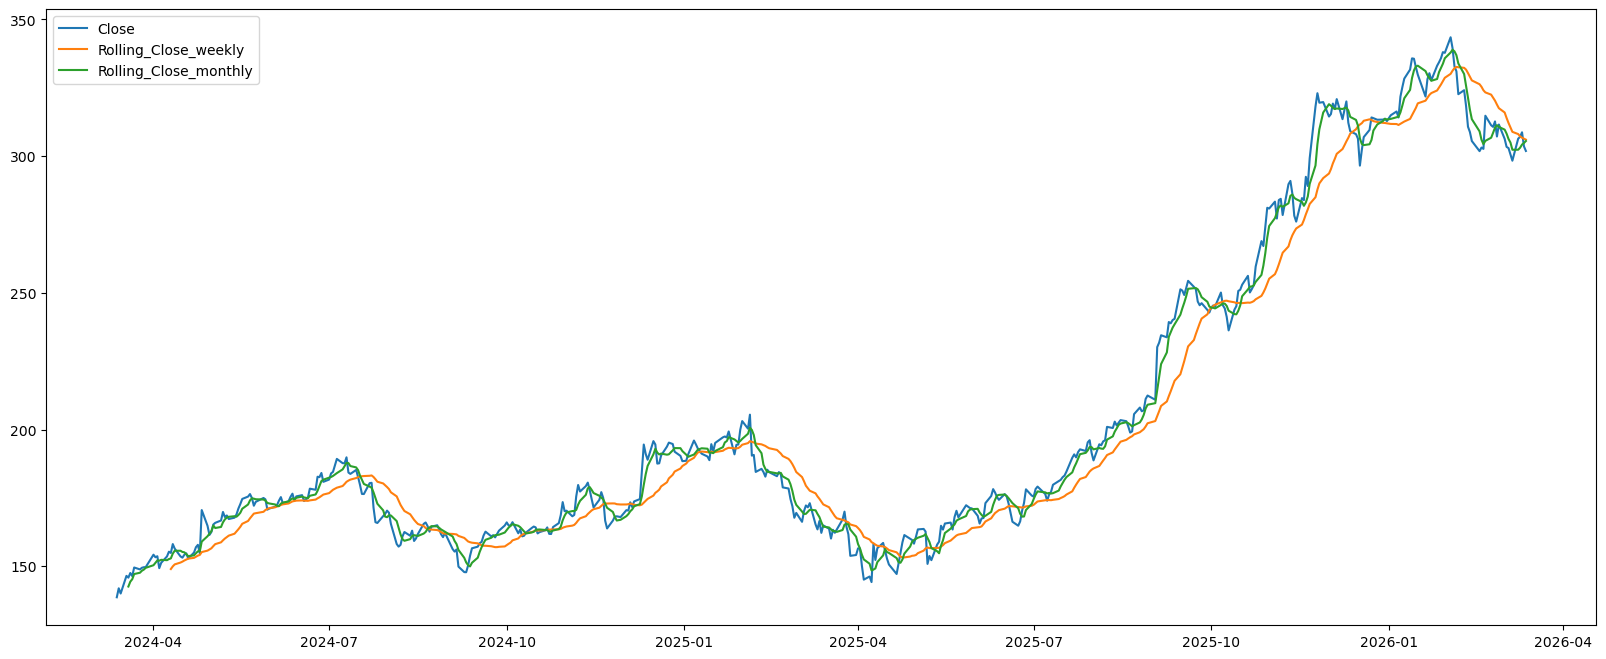

In [43]:
# Visualizing Closing rate - daily, weekly , monthly
plt.figure(figsize=(20,8))
plt.plot(df_ml.Date,df_ml.Close)
plt.plot(df_ml.Date ,df_ml.Close_Roll_monthly)
plt.plot(df_ml.Date ,df_ml.Close_Roll_weekly)

plt.legend(['Close','Rolling_Close_weekly','Rolling_Close_monthly'])

Text(0.5, 1.0, 'Average Weekly Closing Rate Year Wise')

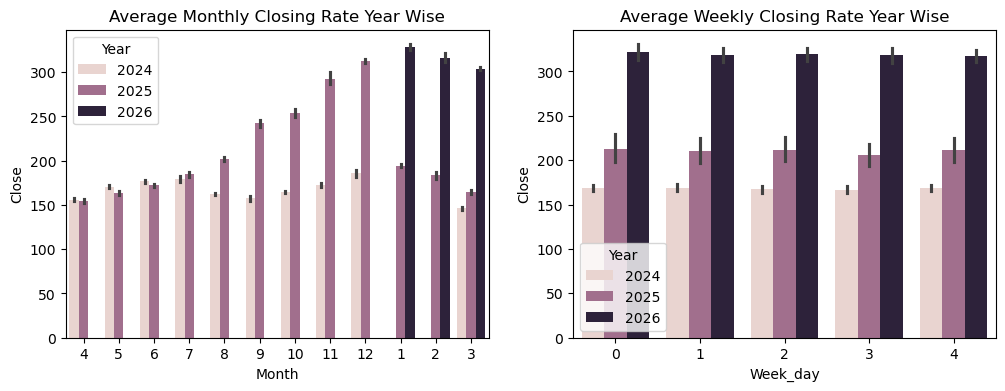

In [44]:
df_ml.head()

# plotting bar plot to see avg CLosing rate month wise for each year
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.barplot(data = df_ml, x = 'Month', y='Close', hue = 'Year',estimator='mean',            # here we take mean of ithe month Closing Rate in a year to get the ith value
            order=[4,5,6,7,8,9,10,11,12,1,2,3])                    # order argument is used to make labels starts from financial month April
plt.title('Average Monthly Closing Rate Year Wise')


plt.subplot(1,2,2)
sns.barplot(data = df_ml, x = 'Week_day', y='Close', hue = 'Year',estimator='mean')                 # here we take mean of ithe week Closing Rate of all month in a year to get the ith value
plt.title('Average Weekly Closing Rate Year Wise')


In [45]:
# tabel for 1st Bar Plot
df_ml.groupby(['Year','Month'])['Close'].mean()
# tabel for 2st Bar Plot
df_ml.groupby(['Year','Week_day'])['Close'].mean()

print("------ INTERPREATION FROM BAR PLOT 1 In Terms of Financial Year ------")
print("""BAR PLOT 1:
      - From FY-2024-25, we observe that the average Closing rate -Starts from FY-2023-24 March with rate of 146.16 rises till July
                                                                  -Sees a small drop from July (178.37) - August (162.420)
                                                                  -Again starts to rise till January
                                                                  -And again reduces to 164 at the end of FY-2024-25 .
      
      - From FY-2025-26, we observe that the average Closing rate -Starts from FY-2025-26 April withrate of 154.02 rises sharply till January
                                                                  -Sees a small drop from January (328.63) - February (316.44)
                                                                  -And  reduces to 303 at the end of FY-2025-26 ie March 2026 .
      
      Overall from the yearly trend we have seen that from the starting of financial month April , the average Closing Rate incrases till January 
      and sees a drop till the nex two months ie end of year at March. """)

------ INTERPREATION FROM BAR PLOT 1 In Terms of Financial Year ------
BAR PLOT 1:
      - From FY-2024-25, we observe that the average Closing rate -Starts from FY-2023-24 March with rate of 146.16 rises till July
                                                                  -Sees a small drop from July (178.37) - August (162.420)
                                                                  -Again starts to rise till January
                                                                  -And again reduces to 164 at the end of FY-2024-25 .

      - From FY-2025-26, we observe that the average Closing rate -Starts from FY-2025-26 April withrate of 154.02 rises sharply till January
                                                                  -Sees a small drop from January (328.63) - February (316.44)
                                                                  -And  reduces to 303 at the end of FY-2025-26 ie March 2026 .

      Overall from the yearly trend we have

In [46]:
df_ml = df_ml.dropna()
df_ml.reset_index(inplace=True,drop=True)
df_ml



,Date,Close,High,Low,Open,Volume,Close_Roll_weekly,Close_Roll_monthly,Week_day,Month,Year,Avg_monthly_closing_rate,Avg_weekly_closing_rate
0,2024-04-10,154.860077,155.326225,153.412038,154.929510,22838600,152.860608,148.969765,2,4,2024,155.898318,167.052491
1,2024-04-11,158.103271,158.371047,155.177457,155.623765,27166400,154.622049,149.942723,3,4,2024,155.898318,166.805580
2,2024-04-12,156.437057,158.906652,155.851897,156.665183,25353700,155.659476,150.668227,4,4,2024,155.898318,168.190089
3,2024-04-15,153.590576,157.934677,153.322785,157.557787,27136500,155.661459,151.346621,0,4,2024,155.898318,168.455819
4,2024-04-16,153.134354,154.374107,152.172304,152.926084,20779500,155.225067,151.679868,1,4,2024,155.898318,169.082667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,2026-03-09,306.359985,306.799988,294.079987,294.359985,29312100,302.324304,308.052924,0,3,2026,303.908588,321.555595
479,2026-03-10,307.040009,309.510010,305.570007,306.170013,23239700,303.059021,307.200331,1,3,2026,303.908588,318.666281
480,2026-03-11,308.700012,311.420013,305.920013,306.750000,24125700,304.215668,306.717538,2,3,2026,303.908588,319.224017
481,2026-03-12,303.549988,308.940002,301.029999,306.820007,24895700,304.791998,306.357976,3,3,2026,303.908588,317.989517


In [47]:
# Start ML MODELING
df = df_ml.copy()
df.head()

,Date,Close,High,Low,Open,Volume,Close_Roll_weekly,Close_Roll_monthly,Week_day,Month,Year,Avg_monthly_closing_rate,Avg_weekly_closing_rate
0,2024-04-10,154.860077,155.326225,153.412038,154.929510,22838600,152.860608,148.969765,2,4,2024,155.898318,167.052491
1,2024-04-11,158.103271,158.371047,155.177457,155.623765,27166400,154.622049,149.942723,3,4,2024,155.898318,166.805580
2,2024-04-12,156.437057,158.906652,155.851897,156.665183,25353700,155.659476,150.668227,4,4,2024,155.898318,168.190089
3,2024-04-15,153.590576,157.934677,153.322785,157.557787,27136500,155.661459,151.346621,0,4,2024,155.898318,168.455819
4,2024-04-16,153.134354,154.374107,152.172304,152.926084,20779500,155.225067,151.679868,1,4,2024,155.898318,169.082667


Close is Not Normal
High is Not Normal
Low is Not Normal
Open is Not Normal
Volume is Not Normal
Close_Roll_weekly is Not Normal
Close_Roll_monthly is Not Normal
Week_day is Not Normal
Month is Not Normal
Year is Not Normal
Avg_monthly_closing_rate is Not Normal
Avg_weekly_closing_rate is Not Normal


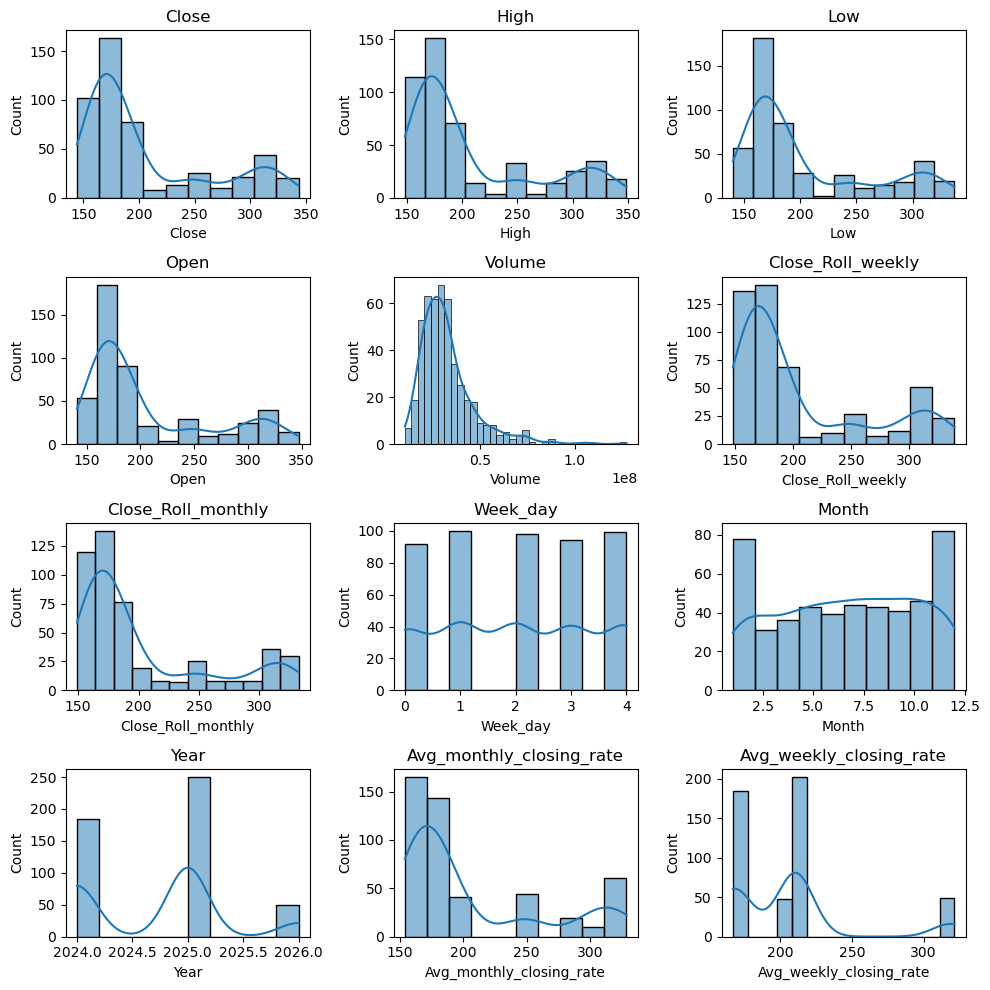

In [48]:
# Step-1 detction of distn and Outliar Detection
plt.figure(figsize=(10,10))

for i,j in enumerate(df.columns[1:]):
    plt.subplot(4,3,i+1)
    sns.histplot(df[j],kde=True,)
    plt.title(df[[j]].columns[0])
    plt.tight_layout()

# Normality Test
from scipy.stats import shapiro

for i,j in enumerate(df.columns[1:]):
    p_val = shapiro(df[[j]])[1]
    if p_val < 0.05:
        print(df[[j]].columns[0], 'is Not Normal')
    else:
        print(df[[j]].columns[0], 'is Normal')

In [49]:
print('Since we are doing Tree Based ML Modelling , so Distribtuon shape and Multicollinearity will not affect the model')

Since we are doing Tree Based ML Modelling , so Distribtuon shape and Multicollinearity will not affect the model


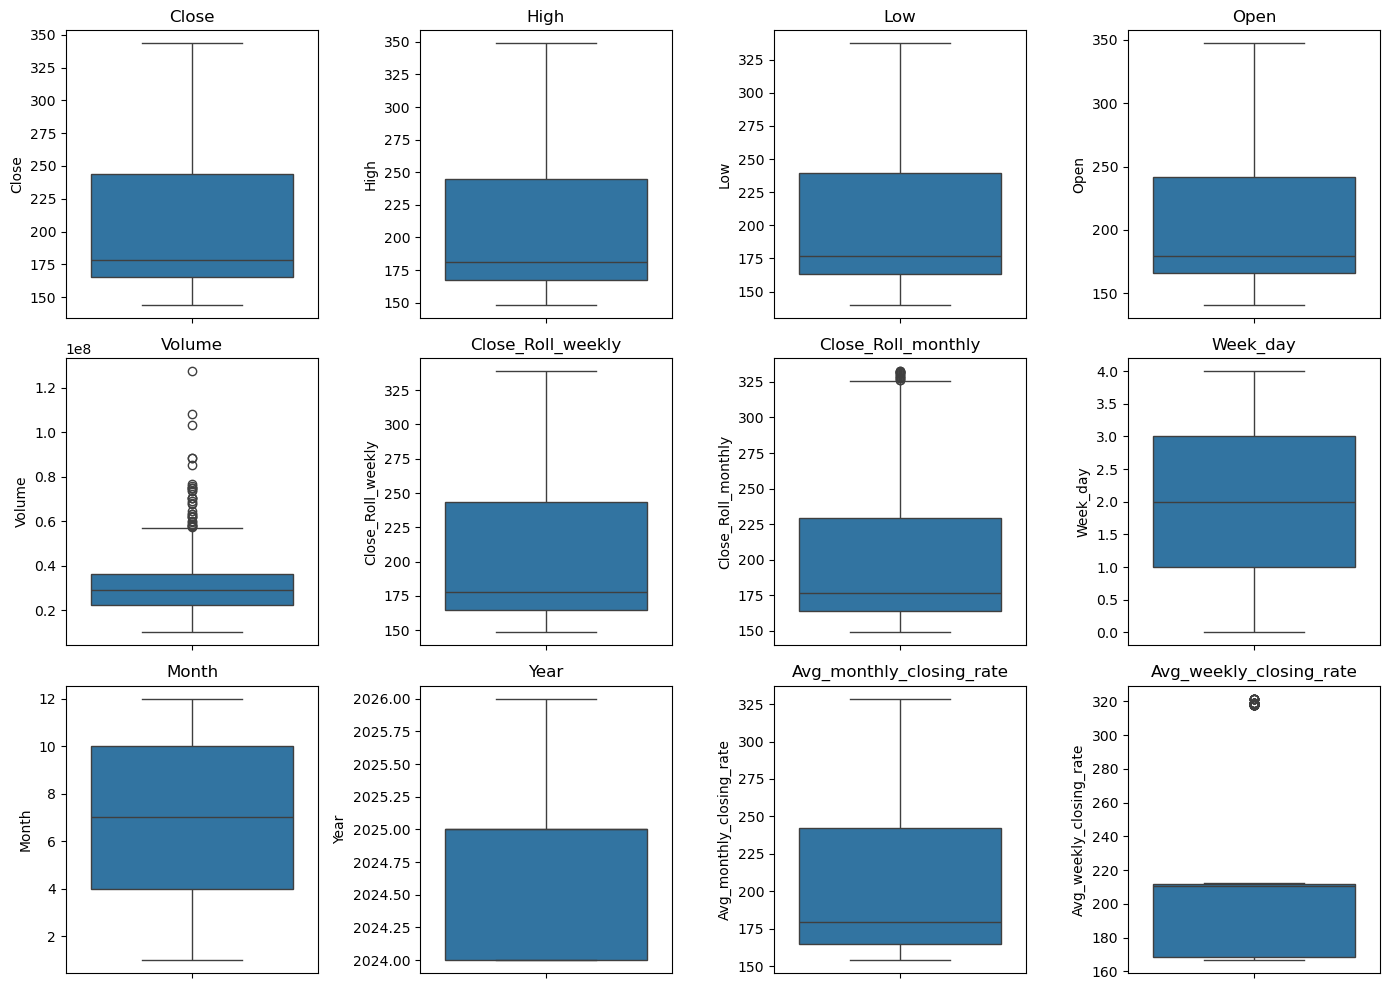

In [50]:
# outliar detection
plt.figure(figsize=(14,10))
for i,j in enumerate(df.columns[1:]):

    plt.subplot(3,4,i+1)
    sns.boxplot(y=df[j])
    plt.title(df[[j]].columns[0])
    plt.tight_layout()


In [51]:
print('From the Boxplots, the features-\nVolume\nCloss_Roll_monthly\nAvg_weekly_closing_rate\nhave outliars')

From the Boxplots, the features-
Volume
Closs_Roll_monthly
Avg_weekly_closing_rate
have outliars


In [52]:
# Defining a func that takes data and tell whether it is normal or not , so that we can use with IQR or z score for outliars

def is_Normal(data):

    from scipy.stats import shapiro
    """Ho: Data is normal
       H1: Data is not normal"""

    statistic, p_val = shapiro(data)
    if p_val < 0.05:
        return print('Reject Ho, Data is not Normal')
    else:
        return print('Fail to reject Ho, Data is Normal')

# Observing Each Features for Outliars 
# and the outliars are not typos and are genuine 
# will not change it

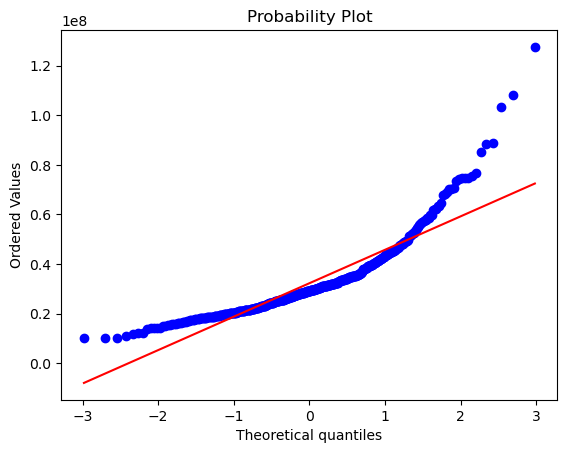

Reject Ho, Data is not Normal


12      64665300
50      57759000
141     68890800
157     59734400
170     67894100
177     63462900
206     70373900
247     62259500
248     76794100
250     70406200
269    127490100
270     57498700
279     73416000
280     74864400
292     61766100
299     75659900
300     57671000
304    108140200
305     63378900
321     58681900
322     74881700
350    103336100
358     58383800
391     74876000
405     68198900
406     62025200
407     74137700
408     85165100
409     88632100
426     59943200
456     70618400
457     88205800
Name: Volume, dtype: int64

In [53]:
from scipy.stats import probplot

# Feature 1 - Volume
probplot(df.Volume,plot=plt)
plt.show()
is_Normal(df.Volume)

# Calculation lower and upper bound for the outliars
q1 = np.quantile(df.Volume,q=0.25)
q3 = np.quantile(df.Volume,q=0.75)
iqr = q3-q1
lb = q1 - 1.5*iqr
ub = q3 + 1.5*iqr
df.query('Volume > @ub or Volume < @lb')['Volume']  # they are  not errors

In [54]:
print("The next two features and engineered, So don't need to change them")

The next two features and engineered, So don't need to change them


In [55]:
# Last step before modelling , creating same lagged features , as we have in SARIMAXSARIMAX(0,1,0)(2,1,0,20) 
# Low - 9lagg , Open - 7 lagg
df['Low_lag9'] = df['Low'].shift(9)
df['Open_lag7'] = df['Open'].shift(7)
df = df.dropna().reset_index(drop=True)


In [56]:
df.head(1)

Y = df.Close
X = df.drop(['Date','Close'],axis=1)


idx = int(len(X)*0.8)
Y_train = Y[:idx+1]
X_train = X[:idx+1]

X_test = X[idx+1:]
Y_test = Y[idx+1:]

In [57]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5, max_train_size=200)

# we will train three models
- RandomFroest
- GradientBoosting
- XGBoost

In [58]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

In [59]:
rf = RandomForestRegressor(n_estimators=100,n_jobs=-1)
gb = GradientBoostingRegressor()
xgb =XGBRegressor(n_jobs=-1)

model = [rf,xgb]

In [60]:
param_rf = {'n_estimators' : [100,200,300],
            'min_samples_split':[10,15,30],
            'max_depth':[3,5,7],
            'min_samples_leaf':[5,10,15],
            'max_features':[5,8]}

param_gb = {'n_estimators' : [100,200,300],
            'learning_rate':[0.1,0.001,10],
            'max_depth':[3,5,7],
            'min_samples_split':[10,15,30],
            'min_samples_leaf':[5,10,15],
            'max_features':[5,8]}


param_xgb = {'n_estimators' : [100,200,300],
             'max_depth':[3,5,7]}

param = [param_rf,param_xgb]

In [ ]:
gcv = [1,2]
for i,j in enumerate(model):
    gcv[i] = GridSearchCV(estimator= j ,param_grid= param[i],cv=tscv).fit(X_train,Y_train)
    
    

In [ ]:
rf_fitted = gcv[0].best_estimator_

from sklearn.metrics import root_mean_squared_error , r2_score
root_mean_squared_error(Y_test,rf_fitted.predict(X_test))
r2_score(Y_test,rf_fitted.predict(X_test))

-10.129985101676032

In [ ]:
xgb_fitted = gcv[1].best_estimator_

from sklearn.metrics import root_mean_squared_error , r2_score
root_mean_squared_error(Y_test,xgb_fitted.predict(X_test))
r2_score(Y_test,xgb_fitted.predict(X_test))

-5.749660852237859

# Getting negative R2 score in both models XG boost  Random Forest It totally means that is we are overfitting

In [ ]:
print('Y_train min and max',min(Y_train),'&',max(Y_train))
print('Y_test min and max',min(Y_test),'&',max(Y_test))

Y_train min and max 144.19998168945312 & 268.9046630859375
Y_test min and max 267.1071472167969 & 343.4482421875


### On observing the minimum and maximum value of training Y and the testing we have found that the minimum and maximum range of training Y is 144 to 268 while for the test range it is 267 to 343 
### So it makes clear why we are getting the negative RT score is because since the ML models are interpolation models not the extrapol so CJ the model is only seen the data between 144 to 268 It is very unlikely that it will predict the values between 267 to 343 as it has never seen any PAT between the range of 267 and 343 so we have do some more feature engineering 


# So we're creating some new features named as return where the return means current value - previous value divided by previous value in percentage

In [160]:
df.columns


Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Close_Roll_weekly',
       'Close_Roll_monthly', 'Week_day', 'Month', 'Year',
       'Avg_monthly_closing_rate', 'Avg_weekly_closing_rate', 'Low_lag9',
       'Open_lag7'],
      dtype='object')

In [161]:
df_ret = pd.DataFrame()

df_ret['Date'] = df['Date']

#Target
df_ret['Ret_Close'] = df['Close'].pct_change()

#Exogenous
df_ret['Ret_High'] = df['High'].pct_change()
df_ret['Ret_Low'] = df['Low'].pct_change()
df_ret['Ret_Open'] = df['Open'].pct_change()
df_ret['Ret_Volume'] = df['Volume'].pct_change()

#Rolling
df_ret['Ret_Close_Roll_weekly'] = df_ret['Ret_Close'].rolling(5).mean()
df_ret['Ret_Close_Roll_monthly'] = df_ret['Ret_Close'].rolling(20).mean()

#Day
df_ret['Week_day'] = df_ret['Date'].dt.day_of_week
df_ret['Month'] = df_ret['Date'].dt.month
df_ret['Year'] = df_ret['Date'].dt.year

#Transform fnc
df_ret['Avg_monthly_closing_ret'] = df_ret.groupby(['Month','Year'])['Ret_Close'].transform('mean')
df_ret['Avg_weekly_closing_ret'] = df_ret.groupby(['Week_day','Year'])['Ret_Close'].transform('mean')

#Lagged exog
df_ret['Ret_Low_lag9'] = df_ret['Ret_Low'].shift(9)
df_ret['Ret_Open_lag7'] = df_ret['Ret_Open'].shift(7)
df_ret['Ret_Close_lag1'] = df_ret['Ret_Close'].shift(1)
df_ret['Ret_Close_lag2'] = df_ret['Ret_Close'].shift(2)

# ##########################################################################################################

# _________________________________________________________________________________________________________

In [162]:
df_ret= df_ret.dropna().reset_index(drop=True)
df_ret

idx = int(len(df_ret)*0.9)

X_train = df_ret.drop(['Date','Ret_Close'],axis=1).iloc[:idx+1]
y_train = df_ret['Ret_Close'].iloc[:idx+1]

X_test = df_ret.drop(['Date','Ret_Close'],axis=1).iloc[idx+1:]
y_test = df_ret['Ret_Close'].iloc[idx+1:]

In [163]:
# Starting From Poly Regression 
# First remove multicollinearity
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
df_ret.corr()['Ret_Close'] [(df_ret.corr()['Ret_Close'] < 0.1 ) | (df_ret.corr()['Ret_Close'] < -0.1) ].index 

X_train_lr = X_train.drop([ 'Ret_Volume', 'Week_day', 'Month', 'Year', 'Ret_Low_lag9',
       'Ret_Open_lag7', 'Ret_Close_lag1', 'Ret_Close_lag2'],axis=1)
X_test_lr = X_test.drop(['Ret_Volume', 'Week_day', 'Month', 'Year', 'Ret_Low_lag9',
       'Ret_Open_lag7', 'Ret_Close_lag1', 'Ret_Close_lag2'],axis=1)

df_ret.drop([ 'Ret_Volume', 'Week_day', 'Month', 'Year', 'Ret_Low_lag9',
       'Ret_Open_lag7', 'Ret_Close_lag1', 'Ret_Close_lag2','Ret_Close','Date'],axis=1).corr()

# High-Low = 0.68
#High-open = 0.67
#Low-open = 0.66
# let see Y
df_ret.corr()['Ret_Close']
# since open has very low corr - let remove it
X_train_lr = X_train_lr.drop(['Ret_Open'],axis=1)
X_test_lr = X_test_lr.drop(['Ret_Open'],axis=1)

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score


sd = StandardScaler()
pf = PolynomialFeatures(3)
ct = ColumnTransformer(transformers=[('pf',pf,[0,1,2,3]),
                                     ('sd',sd,[0,1,2,3,4,5])], remainder='passthrough')

lr = ElasticNet(l1_ratio=0,alpha=0.00001)
pipe = Pipeline(steps=[('s1',ct),
                       ('m1',lr)])

pipe.fit(X_train_lr,y_train)
r2_score(y_test,pipe.predict(X_test_lr))

c:\Users\Dev\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.425e-02, tolerance: 1.467e-05
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


-0.014724911024881493

## MLR Fails

In [68]:
#  Random Forest 
rf = RandomForestRegressor(random_state=9,n_jobs=-1)
rf = GridSearchCV(estimator=rf, param_grid={'max_depth':[3,7,11],
                                            'min_samples_split':[3,5,7,11],
                                            'max_features':[3,5,7,9],
                                            'bootstrap':[True]
                                            },cv=tscv)
rf.fit(X_train,y_train)
print(rf.best_params_)
r2_score(y_test,rf.predict(X_test))

{'bootstrap': True, 'max_depth': 11, 'max_features': 9, 'min_samples_split': 3}


0.44286945822872537

In [ ]:
rf = rf.best_estimator_
rf.feature_importances_

array([0.31240691, 0.42748096, 0.05581687, 0.05457   , 0.03631561,
       0.01140074, 0.00279935, 0.00609622, 0.00112877, 0.00751832,
       0.00698335, 0.01156133, 0.01936268, 0.03585958, 0.01069932])

In [ ]:
# Gradient Boosting
gb = GradientBoostingRegressor(random_state=49)
gb = GridSearchCV(estimator=gb, param_grid={'loss':['squared_error'],
                                            'learning_rate':[0.001,0.1,0.3],
                                            'max_depth':[2,4,6],
                                            'min_samples_leaf':[3,5,8]}
                                            ,cv=tscv)

gb.fit(X_train,y_train)
print(gb.best_params_)
gb = gb.best_estimator_
r2_score(y_test,gb.predict(X_test))

{'learning_rate': 0.1, 'loss': 'squared_error', 'max_depth': 2, 'min_samples_leaf': 3}


0.4983535844940974

In [ ]:
# XGBoost
xg = XGBRegressor(n_jobs=-1,random_state=49)
xg = GridSearchCV(estimator=xg, param_grid={'n_estimators' : [100,300,500],
                                            'learning_rate':[0.001,0.1,0.3],
                                            'max_depth':[2,4,6],
                                            'min_samples_leaf':[3,5,8],
                                            'gamma':[0,0.0000000000001]}
                                            ,cv=tscv)

xg.fit(X_train,y_train)
print(xg.best_params_)
xg = xg.best_estimator_
r2_score(y_test,xg.predict(X_test))

{'gamma': 0, 'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 3, 'n_estimators': 100}


0.43420525798474996

In [ ]:
# Bagging 
bg = BaggingRegressor(estimator=rf,n_estimators=100,n_jobs=-1 )
bg.fit(X_train,y_train)

r2_score(y_test,bg.predict(X_test))

0.511225416657638

In [ ]:
# Voting
from sklearn.ensemble import VotingRegressor

vg = VotingRegressor(estimators=[('rf1',RandomForestRegressor(max_depth= 7, max_features= 9,min_samples_split= 5)),
                                 ('rf5',RandomForestRegressor(max_depth= 8, max_features= 7,min_samples_split= 8)),
                                 ('gb1',GradientBoostingRegressor(learning_rate= 0.1, max_depth= 2, min_samples_leaf= 3)),
                                 ('gb3',GradientBoostingRegressor(learning_rate= 0.7, max_depth= 3, min_samples_leaf= 8)),
                                 ('gb4',GradientBoostingRegressor(learning_rate= 0.2, max_depth= 5, min_samples_leaf= 5)),
                                 ('xg2',XGBRegressor(learning_rate= 0.01,max_depth= 1,min_samples_leaf= 7,n_estimators= 90)),
                                
                                 ],
                                 n_jobs=-1 )
vg.fit(X_train,y_train)

r2_score(y_test,vg.predict(X_test))

0.5492820860503382

In [ ]:
##AGAIN FROM SCRATCH####
#######################33
#######################3
########################

In [173]:
df
# df= df.drop(['Week_day','Month','Year'],axis=1)
df.head(4)

,Date,Close,High,Low,Open,Volume,Close_Roll_weekly,Close_Roll_monthly,Week_day,Month,Year,Avg_monthly_closing_rate,Avg_weekly_closing_rate,Low_lag9,Open_lag7
0,2024-04-23,156.962677,157.666864,154.998912,155.673346,21151600,154.743042,153.460150,1,4,2024,155.898318,169.082667,153.412038,156.665183
1,2024-04-24,157.825562,158.261957,155.881622,156.199006,22779100,155.469043,153.879682,2,4,2024,155.898318,167.052491,155.177457,157.557787
2,2024-04-25,154.721222,155.207211,149.633269,150.089505,57109700,155.467056,154.134079,3,4,2024,155.898318,166.805580,155.851897,152.926084
3,2024-04-26,170.540497,173.277882,168.259347,172.940658,64665300,159.009778,155.176465,4,4,2024,155.898318,168.190089,153.322785,154.344321


In [174]:
#### Creating new dataframe return df
df2 = pd.DataFrame()

#Daily %age change in base variables
df2['Date'] = df['Date']
for i in df.columns[1:6]:
    df2[f'{i}_Return'] = df[i].pct_change(1)

# df2 = df2.dropna()

# Intraday return - How much stock moved during trading hours It captures the intraday market sentiment and trading activity 
# It also shows if stocks gained or lost momentum during the day 
df2['Intraday_return'] = (df['Close'] - df['Open'])/ df['Open']

# Gap return. It is the price jump between yesterday's close and today's open. It captures the overnight sentiment
df2['Gap_Return'] = df['Open'] - df['Close'].shift(1)

# Multi. returns It is the return over multiple days like two days, five days etc. It captures longer term movement trends
for i in [2,5,10]:
    df2[f'Retrun_{i}d_Close'] = df['Close'].pct_change(i)

# Multi lagged return closing rates Up to 3
for i in [1,2,3]:
    df2[f'Close_Return_lag{i}'] = df2['Close_Return'].shift(i)

# Volatility features. It is the standard deviation of returns over past NDS. It captures how jumpy are unstable the stock has been
for i in [2,5,10]:
    df2[f'Volatility_{i}d'] = df2['Close_Return'].rolling(i).std()

# Volatility ratio It is the recent volatility compared to longer term volatility. What it captures is that volatility Creases or decreases It is important because rising volatility often signals trend changes. 

df2[f'Volatility_ratio_2/5'] = df2['Volatility_2d']/df2['Volatility_5d']
df2[f'Volatility_ratio_2/10'] = df2['Volatility_2d']/df2['Volatility_10d']
df2[f'Volatility_ratio_5/10'] = df2['Volatility_5d']/df2['Volatility_10d']

#Exogenous 
df2['High_Return_lag6'] = df2['High_Return'].shift(6)
df2['Low_Return_lag9']  = df2['Low_Return'].shift(9)
df2['Open_Return_lag7'] = df2['Open_Return'].shift(7)

df2.head(7)

,Date,Close_Return,High_Return,Low_Return,Open_Return,Volume_Return,Intraday_return,Gap_Return,Retrun_2d_Close,Retrun_5d_Close,...,Close_Return_lag3,Volatility_2d,Volatility_5d,Volatility_10d,Volatility_ratio_2/5,Volatility_ratio_2/10,Volatility_ratio_5/10,High_Return_lag6,Low_Return_lag9,Open_Return_lag7
0,2024-04-23,NaN,NaN,NaN,NaN,NaN,0.008282,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-04-24,0.005497,0.003774,0.005695,0.003377,0.076945,0.010413,-0.763671,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-04-25,-0.019669,-0.019302,-0.040084,-0.039114,1.507110,0.030860,-7.736056,-0.014280,NaN,...,NaN,0.017796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-04-26,0.102244,0.116429,0.124478,0.152250,0.132300,-0.013879,18.219436,0.080563,NaN,...,NaN,0.086206,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-04-29,-0.033731,-0.029535,-0.026172,-0.030453,-0.294676,-0.017213,-2.866322,0.065064,NaN,...,0.005497,0.096149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2024-04-30,-0.020283,-0.008552,-0.015798,-0.020407,-0.264133,-0.017088,-0.535558,-0.053329,0.028561,...,-0.019669,0.009509,0.055200,NaN,0.172269,NaN,NaN,NaN,NaN,NaN
6,2024-05-01,0.006635,-0.005830,0.003013,-0.007910,-0.002077,-0.002678,1.507547,-0.013783,0.029724,...,0.102244,0.019034,0.055195,NaN,0.344840,NaN,NaN,NaN,NaN,NaN


In [175]:
df2 = df2.dropna().reset_index(drop=True)
df2

,Date,Close_Return,High_Return,Low_Return,Open_Return,Volume_Return,Intraday_return,Gap_Return,Retrun_2d_Close,Retrun_5d_Close,...,Close_Return_lag3,Volatility_2d,Volatility_5d,Volatility_10d,Volatility_ratio_2/5,Volatility_ratio_2/10,Volatility_ratio_5/10,High_Return_lag6,Low_Return_lag9,Open_Return_lag7
0,2024-05-07,0.018739,0.021530,0.014214,0.006210,0.282032,0.016320,0.396703,0.023978,0.052033,...,0.016844,0.009614,0.007023,0.037140,1.368854,0.258861,0.189108,-0.029535,0.005695,0.152250
1,2024-05-08,-0.010920,-0.009373,0.002079,0.002967,-0.302093,0.002249,-2.231535,0.007615,0.033687,...,0.003721,0.020972,0.011933,0.037647,1.757464,0.557052,0.316964,-0.008552,-0.040084,-0.030453
2,2024-05-09,0.003424,0.003174,-0.003319,0.002308,-0.215769,0.003365,0.009921,-0.007533,0.020046,...,0.005142,0.010143,0.010506,0.036530,0.965380,0.277652,0.287608,-0.005830,0.124478,-0.020407
3,2024-05-10,-0.007708,-0.004921,-0.011832,-0.008029,0.941779,0.003690,-1.914168,-0.004310,0.008431,...,0.018739,0.007871,0.011757,0.016417,0.669525,0.479459,0.716118,-0.002334,-0.026172,-0.007910
4,2024-05-13,0.002905,-0.003356,-0.013178,-0.022437,0.051265,0.029709,-4.354055,-0.004825,0.006187,...,-0.010920,0.007504,0.011637,0.011996,0.644892,0.625578,0.970051,0.007377,-0.015798,0.002982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459,2026-03-09,0.026985,0.021582,-0.003025,-0.005143,0.146038,0.040766,-3.950012,0.018930,0.000182,...,-0.001482,0.024628,0.015321,0.013977,1.607450,1.762021,1.096159,-0.002459,-0.012715,0.001859
460,2026-03-10,0.002220,0.008833,0.039071,0.040121,-0.207164,0.002842,-0.189972,0.029265,0.012109,...,-0.007423,0.017512,0.014326,0.014025,1.222404,1.248656,1.021475,-0.012421,0.011473,-0.027188
461,2026-03-11,0.005406,0.006171,0.001145,0.001894,0.038124,0.006357,-0.290009,0.007638,0.019092,...,-0.007844,0.002253,0.014179,0.013967,0.158929,0.161336,1.015146,-0.014749,-0.022912,-0.002992
462,2026-03-12,-0.016683,-0.007964,-0.015985,0.000228,0.031916,-0.010658,-1.880005,-0.011367,0.009584,...,0.026985,0.015620,0.016446,0.013844,0.949757,1.128220,1.187904,0.005034,0.004796,-0.015302


In [176]:
idx = int(len(df2)*0.9)

X_train = df2.drop(['Date','Close_Return'],axis=1).iloc[:idx+1]
y_train = df2['Close_Return'].iloc[:idx+1]

X_test = df2.drop(['Date','Close_Return'],axis=1).iloc[idx+1:]
y_test = df2['Close_Return'].iloc[idx+1:]

In [177]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(5)

In [ ]:
#  Random Forest 
rf = RandomForestRegressor(random_state=9,n_jobs=-1)
rf = GridSearchCV(estimator=rf, param_grid={'max_depth':[3,7,11],
                                            'min_samples_split':[3,5,7,11],
                                            'max_features':[3,5,7,9],
                                            'bootstrap':[True]
                                            },cv=tscv)
rf.fit(X_train,y_train)
print(rf.best_params_)
r2_score(y_test,rf.predict(X_test))

# gcv 1st time then {'bootstrap': True, 'max_depth': 11, 'max_features': 9, 'min_samples_split': 3}

{'bootstrap': True, 'max_depth': 11, 'max_features': 9, 'min_samples_split': 3}


0.8488958231718371

In [104]:
rf = RandomForestRegressor(random_state=9,n_jobs=-1,bootstrap= True, 
                           max_depth= 11,max_features=9,min_samples_split= 3)
rf.fit(X_train,y_train)
# print(rf.best_params_)
r2_score(y_test,rf.predict(X_test))


0.8519213962519849

In [ ]:
# Gradient Boosting
gb = GradientBoostingRegressor(random_state=49)
gb = GridSearchCV(estimator=gb, param_grid={'loss':['squared_error'],
                                            'learning_rate':[0.001,0.1,0.3],
                                            'max_depth':[2,4,6],
                                            'min_samples_leaf':[5,8,10,12]}
                                            ,cv=tscv)

gb.fit(X_train,y_train)
print(gb.best_params_)
gb = gb.best_estimator_
r2_score(y_test,gb.predict(X_test))

# on gcv 1st time {'learning_rate': 0.1, 'loss': 'squared_error', 'max_depth': 4, 'min_samples_leaf': 8}

{'learning_rate': 0.1, 'loss': 'squared_error', 'max_depth': 4, 'min_samples_leaf': 5}


0.8197668647982143

In [79]:
gb = GradientBoostingRegressor(random_state=49,learning_rate =  0.1, 
                               loss= 'squared_error', max_depth= 4, min_samples_leaf= 5)

gb.fit(X_train,y_train)
r2_score(y_test,gb.predict(X_test))

0.8179180135468318

In [ ]:
# XGBoost
xg = XGBRegressor(n_jobs=-1,random_state=49)
xg = GridSearchCV(estimator=xg, param_grid={'n_estimators' : [100],
                                            'learning_rate':[0.01,0.05,0.1,0.3],
                                            'max_depth':[2,4,6],
                                            'min_samples_leaf':[1,2,3,6],
                                            'gamma':[0]}
                                            ,cv=tscv)

xg.fit(X_train,y_train)
print(xg.best_params_)
xg = xg.best_estimator_
r2_score(y_test,xg.predict(X_test))

#on 1st gcv we get {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 1, 'n_estimators': 100}

{'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 1, 'n_estimators': 100}


0.7976798647596963

In [75]:
xg = XGBRegressor(n_jobs=-1,random_state=49,gamma= 0, learning_rate= 0.1,
                  max_depth= 4, min_samples_leaf= 1, n_estimators= 100)
xg.fit(X_train,y_train)
r2_score(y_test,xg.predict(X_test))

c:\Users\Dev\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:51:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


0.8511243083187382

In [80]:
# Voting
from sklearn.ensemble import VotingRegressor

vg = VotingRegressor(estimators=[('rf',rf),
                                 ('gb',gb),
                                 ('xgb',xg)
                                 ],
                                 n_jobs=-1 )
vg.fit(X_train,y_train)

r2_score(y_test,vg.predict(X_test))

0.8542959663183827

In [178]:
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error

Evaluation = pd.DataFrame()
Evaluation['Models'] = ['RandomForest','Gradient Boosting','XGBoost','VotingRegressor']

models = [rf,gb,xg,vg]

r2_train=[]
r2_test = []

rmse_train=[]
rmse_test = []

mape_train=[]
mape_test = []

ts_train = []
ts_test = []
for i in models:

    #R2_Score
    r2_train.append(r2_score(y_train,i.predict(X_train)))
    r2_test.append(r2_score(y_test,i.predict(X_test)))

    #RMSE
    
    rmse_train.append(root_mean_squared_error(y_train,i.predict(X_train)))
    rmse_test.append(root_mean_squared_error(y_test,i.predict(X_test)))

    #MAPE
    mape_train.append(mean_absolute_error(y_train,i.predict(X_train)))
    mape_test.append(mean_absolute_error(y_test,i.predict(X_test)))

    #TRACKING SIGNAL
    cfe_train = sum((y_train - i.predict(X_train)))     #Cumulative forecast error
    mad_train = sum(abs(y_train - i.predict(X_train)))/len(X_train)

    
    cfe_test = sum((y_test - i.predict(X_test)))     #Cumulative forecast error
    mad_test = sum(abs(y_test - i.predict(X_test)))/len(X_test)
    
    ts_train.append(cfe_train/mad_train)
    ts_test.append(cfe_test/mad_test)

Evaluation['Train_R2'] = r2_train
Evaluation['Test_R2'] = r2_test
Evaluation['Train_RMSE'] = rmse_train
Evaluation['Test_RMSE'] = rmse_test
Evaluation['Train_MAE'] =np.round(mape_train,6)
Evaluation['Test_MAE'] = np.round(mape_test,6)
Evaluation['Train_Tracking_Signal'] = np.round(ts_train,8)
Evaluation['Test_Tracking_Signal'] = np.round(ts_test,8)
Evaluation['Overfit_gap'] = Evaluation.Train_R2 - Evaluation.Test_R2

Evaluation

,Models,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_Tracking_Signal,Test_Tracking_Signal,Overfit_gap
0,RandomForest,0.981189,0.851921,0.002572,0.005430,0.001534,0.003968,-18.584113,5.003840,0.129267
1,Gradient Boosting,0.998093,0.817918,0.000819,0.006021,0.000625,0.004420,-0.000000,0.538092,0.180175
2,XGBoost,0.998255,0.851124,0.000783,0.005444,0.000612,0.004030,-0.081074,8.249602,0.147131
3,VotingRegressor,0.996057,0.854296,0.001178,0.005386,0.000813,0.003939,-11.712790,4.695280,0.141761


# FINAL MODEL -  Random Forest with hyperparameters ['bootstrap': True, 'max_depth': 11, 'max_features': 9, 'min_samples_split': 3] is  best model — wins on every metric that matters:


- Highest Test R² (0.85)
- Lowest Test RMSE (0.0054)
- Lowest Test MAE (0.004)
- Smallest overfitting gap (0.130)

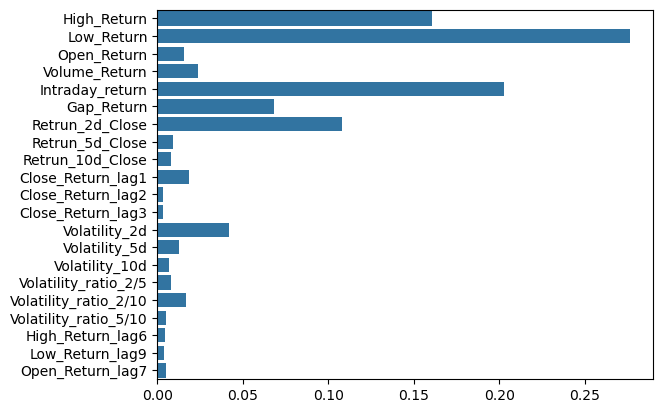

In [179]:
feature_imp = rf.feature_importances_
feature_name = rf.feature_names_in_

sns.barplot(y=feature_name , x= feature_imp)
feat_imp = pd.DataFrame({'Feature':feature_name,
                    'feature_importance':feature_imp})

# After rebuilding Random Forest while excluding the features with imp < 0.005 , we get negative R2 , no feature reduction is possible.

In [180]:
for j in [40,45,60,70]:
    rf2 = RandomForestRegressor(random_state=j,n_jobs=-1,bootstrap= True, 
                            max_depth= 11,max_features=9,min_samples_split= 3)

    k = [0.001,0.003,0.004,0.005,0.007,0.01]
    for i in k:
        X_train_2 = X_train.iloc[:,feat_imp['feature_importance'][feat_imp['feature_importance'] >= i].index]
        rf2.fit(X_train_2,y_train)
        r2 = r2_score(y_test,rf2.predict(X_test.iloc[:,feat_imp['feature_importance'][feat_imp['feature_importance'] >= i].index]))


        print('random_state', j ,'Threshold', i ,"R2", r2)

random_state 40 Threshold 0.001 R2 0.8350861768233263
random_state 40 Threshold 0.003 R2 0.8420341708439607
random_state 40 Threshold 0.004 R2 0.8470397639275329
random_state 40 Threshold 0.005 R2 0.8553239245312265
random_state 40 Threshold 0.007 R2 0.8591041174772353
random_state 40 Threshold 0.01 R2 0.831376768644764
random_state 45 Threshold 0.001 R2 0.8288210726757823
random_state 45 Threshold 0.003 R2 0.8479852991021789
random_state 45 Threshold 0.004 R2 0.829065830401228
random_state 45 Threshold 0.005 R2 0.8172437714726035
random_state 45 Threshold 0.007 R2 0.8306872564615154
random_state 45 Threshold 0.01 R2 0.8259919358620801
random_state 60 Threshold 0.001 R2 0.860419964459472
random_state 60 Threshold 0.003 R2 0.8297422847916203
random_state 60 Threshold 0.004 R2 0.8329997316133783
random_state 60 Threshold 0.005 R2 0.8285971414806792
random_state 60 Threshold 0.007 R2 0.8265838981706871
random_state 60 Threshold 0.01 R2 0.8146397361003779
random_state 70 Threshold 0.001 R2

In [182]:
X_train2 = X_train.iloc[:,feat_imp['feature_importance'][feat_imp['feature_importance'] >= 0.004].index]
X_test2 = X_test.iloc[:,feat_imp['feature_importance'][feat_imp['feature_importance'] >= 0.004].index]

rf2 = RandomForestRegressor(random_state=1,n_jobs=-1,bootstrap= True, 
                            max_depth= 11,max_features=9,min_samples_split= 3)
rf2.fit(X_train2,y_train)

print('RMSE of Train ',root_mean_squared_error(y_train,rf2.predict(X_train2)))
print('RMSE of Test ',root_mean_squared_error(y_test,rf2.predict(X_test2)))


print('R2 of Train ',r2_score(y_train,rf2.predict(X_train2)))
print('R2 of Test ',r2_score(y_test,rf2.predict(X_test2)))

RMSE of Train  0.0023876839827707934
RMSE of Test  0.0052139603111507294
R2 of Train  0.9837908814159803
R2 of Test  0.8634456842510397


In [190]:
feat_imp[feat_imp['feature_importance']<0.004]
feat_imp['Feature'][feat_imp['feature_importance']>0.004].values

array(['High_Return', 'Low_Return', 'Open_Return', 'Volume_Return',
       'Intraday_return', 'Gap_Return', 'Retrun_2d_Close',
       'Retrun_5d_Close', 'Retrun_10d_Close', 'Close_Return_lag1',
       'Volatility_2d', 'Volatility_5d', 'Volatility_10d',
       'Volatility_ratio_2/5', 'Volatility_ratio_2/10',
       'Volatility_ratio_5/10', 'High_Return_lag6', 'Open_Return_lag7'],
      dtype=object)